# Results Notebook

Trains all five models, saves their results for comparison and presentation.

In [4]:
# imports
import json
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from src.data.loader import load_dataset
from src.data.resampler import resample
from src.models.evaluation import (
	evaluate_model_predictions,
	save_classification_report,
	build_metrics_leaderboard,
    plot_confusion_matrix
)
from src.visualization.data_visualization import (
	save_f1_chart,
	save_f1_comparison_chart,
	save_training_curves
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

### Loading and Resampling Data

In [3]:
# load the dataset

df = load_dataset()
print(f"Loaded {df.shape[0]} samples with {df.shape[1]} features.")

X = df.drop("Label", axis=1)
y = df["Label"]

Loading cleaned dataset from cache at cache/cleaned.parquet
Loaded 2522362 samples with 62 features.


In [6]:
# 70% train, 30% tmp (test + val)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Split tmp into 50% test, 50% val (=> 15% each of full dataset)
X_test, X_val, y_test, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

print(f"Total samples: {X_train.shape[0] + X_test.shape[0] + X_val.shape[0]} samples")

Training set: 2017889 samples
Test set: 252236 samples
Validation set: 252237 samples
Total samples: 2522362 samples


In [7]:
# save test set for later
test_df = X_test.copy()
test_df["Label"] = y_test.values
test_df.to_parquet(RESULTS / "test_set.parquet", index=False)

print(f"Saved demo set to results/test_set.parquet, with {test_df.shape[0]} samples.")

Saved demo set to results/test_set.parquet, with 252236 samples.


In [8]:
# resample the training set for class imbalance
X_resampled, y_resampled = resample(X_train, y_train)

Resampled class distribution:
Label
BENIGN                        500000
DoS Hulk                      138279
DDoS                          102413
PortScan                       72655
DoS GoldenEye                   8229
Bot                             5000
SSH-Patator                     5000
Web Attack - Brute Force        5000
Web Attack - XSS                5000
FTP-Patator                     4746
DoS slowloris                   4308
DoS Slowhttptest                4182
Infiltration                    2000
Web Attack - Sql Injection      2000
Heartbleed                      1000


### Model Training

In [9]:
import time
# logistic regression training
from src.models.logistic import train_logistic_classifier, predict_labels as lr_predict

t0 = time.time()
lr_artifacts = train_logistic_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	solver='newton-cholesky',
	max_iter=100,
	verbose=1
)
lr_train_time = time.time() - t0
print(f"Logistic regression training complete. ({lr_train_time:.1f}s)")


Newton iter=1


KeyboardInterrupt: 

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.865     0.927    314472
                  DoS Hulk      0.899     0.997     0.945     25927
                  PortScan      0.708     0.998     0.829     13623
                      DDoS      0.852     0.999     0.920     19202
               FTP-Patator      0.550     0.993     0.708       890
             DoS GoldenEye      0.639     0.978     0.773      1543
             DoS slowloris      0.456     0.978     0.622       807
                       Bot      0.017     0.976     0.034       293
               SSH-Patator      0.409     0.913     0.565       483
          Web Attack - XSS      0.022     0.796     0.043        98
  Web Attack - Brute Force      0.062     0.493     0.109       221
          DoS Slowhttptest      0.305     0.977     0.465       784
Web Attack - Sql Injection      0.001     1.000     0.002         3
              Infiltration      0.002     0.667

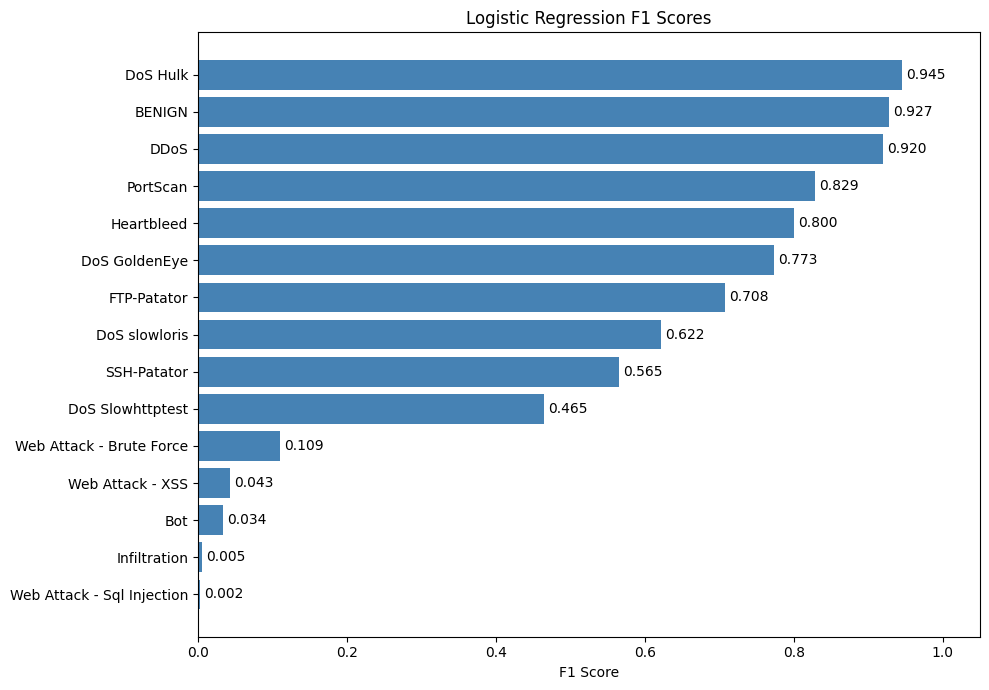

Saved results/logistic_f1_chart.png


In [9]:
# logistic regression evaluation
lr_result = evaluate_model_predictions("Logistic Regression", y_test, lr_predict(lr_artifacts, X_test))
save_classification_report(lr_result, RESULTS / "logistic_report.txt")

lr_report_dict = lr_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "logistic_report.json").write_text(json.dumps(lr_report_dict))

with open(RESULTS / "logistic_artifacts.pkl", "wb") as f:
    pickle.dump(lr_artifacts, f)

print(lr_result.classification_report_text)

save_f1_chart(
	lr_report_dict,
	title="Logistic Regression F1 Scores",
	save_path=str(RESULTS / "logistic_f1_chart.png")
)

In [23]:
import time
# random forest training
from src.models.rf import train_rf_classifier, predict_labels as rf_predict

t0 = time.time()
rf_artifacts = train_rf_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	n_estimators=200,
	max_depth=100,
)
rf_train_time = time.time() - t0
print(f"Random forest training complete. ({rf_train_time:.1f}s)")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   19.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.8min


Random forest training complete.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.0min finished


In [31]:
depths = [tree.tree_.max_depth for tree in rf_artifacts.model.estimators_]
print(max(depths))

70


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    1.3s finished


                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    314472
                  DoS Hulk      0.994     0.999     0.996     25927
                  PortScan      0.990     0.999     0.994     13623
                      DDoS      0.999     1.000     1.000     19202
               FTP-Patator      0.999     1.000     0.999       890
             DoS GoldenEye      0.984     0.996     0.990      1543
             DoS slowloris      0.988     0.988     0.988       807
                       Bot      0.491     0.962     0.651       293
               SSH-Patator      0.986     0.996     0.991       483
          Web Attack - XSS      0.397     0.531     0.454        98
  Web Attack - Brute Force      0.745     0.688     0.715       221
          DoS Slowhttptest      0.973     0.992     0.982       784
Web Attack - Sql Injection      0.400     0.667     0.500         3
              Infiltration      1.000     0.500

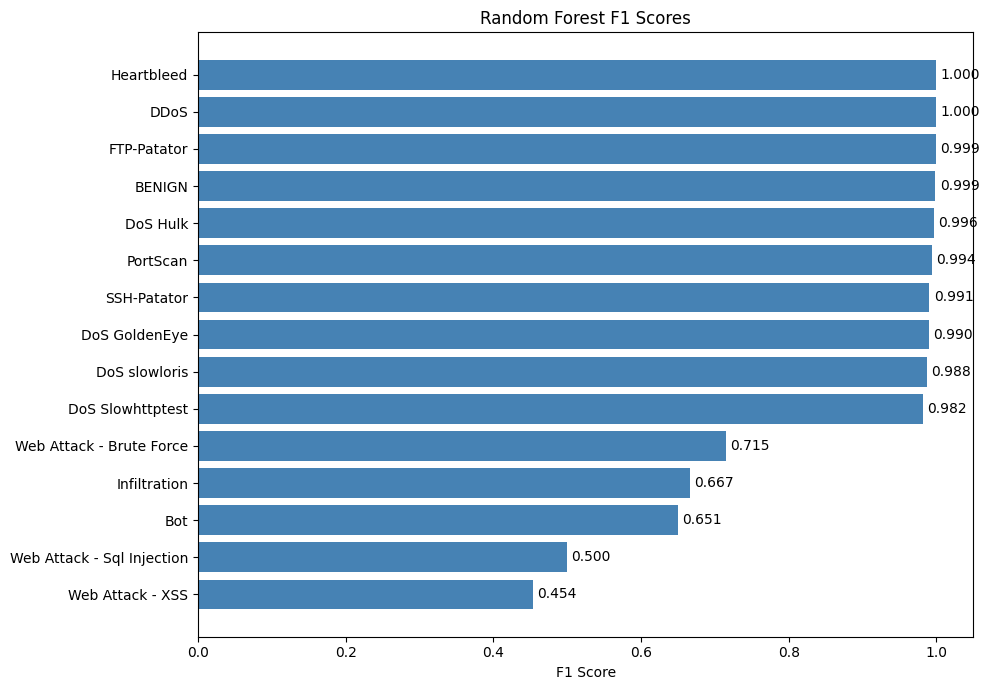

Saved results/rf_f1_chart.png


In [25]:
# rf evaluation

rf_result = evaluate_model_predictions("Random Forest", y_test, rf_predict(rf_artifacts, X_test))
save_classification_report(rf_result, RESULTS / "rf_report.txt")

rf_report_dict = rf_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "rf_report.json").write_text(json.dumps(rf_report_dict))

with open(RESULTS / "rf_artifacts.pkl", "wb") as f:
	pickle.dump(rf_artifacts, f)

print(rf_result.classification_report_text)

save_f1_chart(
	rf_report_dict,
	title="Random Forest F1 Scores",
	save_path=str(RESULTS / "rf_f1_chart.png")
)

In [14]:
import time
# train lightgbm classifier
from src.models.lgbm import train_lightgbm_classifier, predict_labels as lgbm_predict

t0 = time.time()
lgbm_artifacts = train_lightgbm_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	class_weight="balanced",
	n_estimators=500,
	early_stopping_rounds=100,
	learning_rate=0.05,
	num_leaves=63,
	random_state=42,
)
lgbm_train_time = time.time() - t0
print(f"LightGBM training complete. ({lgbm_train_time:.1f}s)")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12560
[LightGBM] [Info] Number of data points in the train set: 1814910, number of used features: 59
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70805

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    314472
                  DoS Hulk      0.998     0.999     0.999     25927
                  PortScan      0.989     0.999     0.994     13623
                      DDoS      0.999     1.000     0.999     19202
               FTP-Patator      0.996     1.000     0.998       890
             DoS GoldenEye      0.987     0.999     0.993      1543
             DoS slowloris      0.969     0.993     0.980       807
                       Bot      0.433     0.990     0.602       293
               SSH-Patator      0.990     1.000     0.995       483
          Web Attack - XSS      0.364     0.571     0.444        98
  Web Attack - Brute Force      0.659     0.638     0.648       221
          DoS Slowhttptest      0.972     0.990     0.981       784
Web Attack - Sql Injection      0.500     0.667     0.571         3
              Infiltration      0.667     1.000

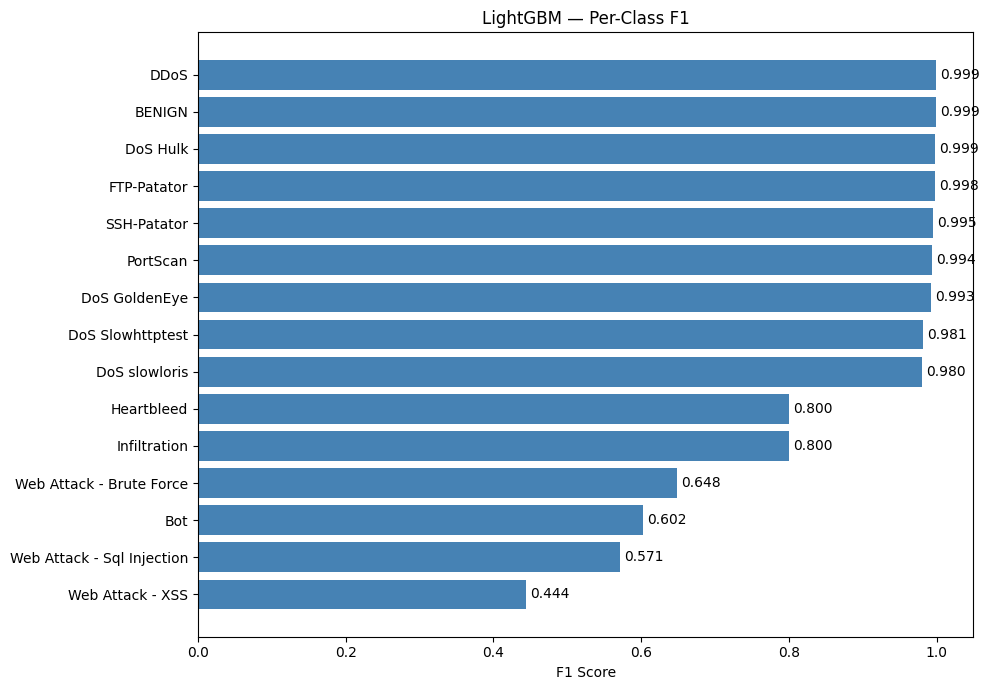

Saved results/lgbm_f1.png


In [15]:
# lightgbm evaluation
lgbm_result = evaluate_model_predictions("LightGBM", y_test, lgbm_predict(lgbm_artifacts, X_test))
save_classification_report(lgbm_result, RESULTS / "lgbm_report.txt")

lgbm_report_dict = lgbm_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "lgbm_report.json").write_text(json.dumps(lgbm_report_dict))

with open(RESULTS / "lgbm_artifacts.pkl", "wb") as f:
    pickle.dump(lgbm_artifacts, f)

print(lgbm_result.classification_report_text)

save_f1_chart(
    lgbm_report_dict,
    title="LightGBM — Per-Class F1",
    save_path=str(RESULTS / "lgbm_f1.png"),
)


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

def make_pca_views(X_train, X_val, X_test, n_components=0.95, random_state=42):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    pca = PCA(n_components=n_components, svd_solver="full", random_state=random_state)
    X_train_p = pca.fit_transform(X_train_s)
    X_val_p = pca.transform(X_val_s)
    X_test_p = pca.transform(X_test_s)
    
    cols = [f"PC{i+1}" for i in range(X_train_p.shape[1])]
    return (
        pd.DataFrame(X_train_p, index=X_train.index, columns=cols),
        pd.DataFrame(X_val_p, index=X_val.index, columns=cols),
        pd.DataFrame(X_test_p, index=X_test.index, columns=cols),
        pca
    )

X_fit_pca, X_val_pca, X_test_pca, pca_cnn = make_pca_views(
    X_resampled, X_val, X_test, n_components=0.95, random_state=42
)
print("CNN PCA components:", pca_cnn.n_components_, "explained var:", pca_cnn.explained_variance_ratio_.sum())


CNN PCA components: 25 explained var: 0.9558585983337966


In [24]:
# mlp training
# Fully-connected neural network with BatchNorm and Dropout. `StandardScaler` and `LabelEncoder` are handled internally. Uses early stopping on validation loss (patience=5). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

mlp_artifacts = train_mlp_classifier(
	X_fit_pca,
	y_resampled,
	X_valid=X_val_pca,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.15,
	random_state=42,
	verbose=1
)
print("MLP training complete.")



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_5 (Normalization) │ (None, 25)             │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,626 (197.76 KB)

 Trainable params: 49,679 (194.06 KB)

 Non-trainable params: 947 (3.70 KB)

None
Epoch 1/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9492 - cross_entropy: 0.1443 - loss: 0.1696 - val_accuracy: 0.9700 - val_cross_entropy: 0.0680 - val_loss: 0.0680
Epoch 2/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9599 - cross_entropy: 0.0976 - loss: 0.0976 - val_accuracy: 0.9709 - val_cross_entropy: 0.0629 - val_loss: 0.0629
Epoch 3/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9635 - cross_entropy: 0.0868 - loss: 0.0868 - val_accuracy: 0.9699 - val_cross_entropy: 0.0648 - val_loss: 0.0648
Epoch 4/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9651 - cross_entropy: 0.0822 - loss: 0.0822 - val_accuracy: 0.9731 - val_cross_entropy: 0.0570 - val_loss: 0.0570
Epoch 5/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9663 - cross_entropy: 0.0789 - loss: 0.0789 - val_accuracy: 0.9674 - val_cross_entropy: 0.0635 - val_loss: 0.0635
Epoch 6/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9670 - cros

                            precision    recall  f1-score   support

                    BENIGN      0.999     0.970     0.984    209648
                  PortScan      0.738     0.998     0.848      9082
                  DoS Hulk      0.896     0.997     0.944     17285
                      DDoS      0.998     0.999     0.998     12801
             DoS GoldenEye      0.962     0.982     0.972      1028
  Web Attack - Brute Force      0.529     0.122     0.199       147
          Web Attack - XSS      0.066     0.969     0.124        65
               SSH-Patator      0.968     0.925     0.946       322
                       Bot      0.551     0.638     0.591       196
             DoS slowloris      0.967     0.978     0.972       539
          DoS Slowhttptest      0.876     0.975     0.923       523
               FTP-Patator      0.978     0.985     0.982       593
              Infiltration      0.273     0.750     0.400         4
Web Attack - Sql Injection      0.036     1.000

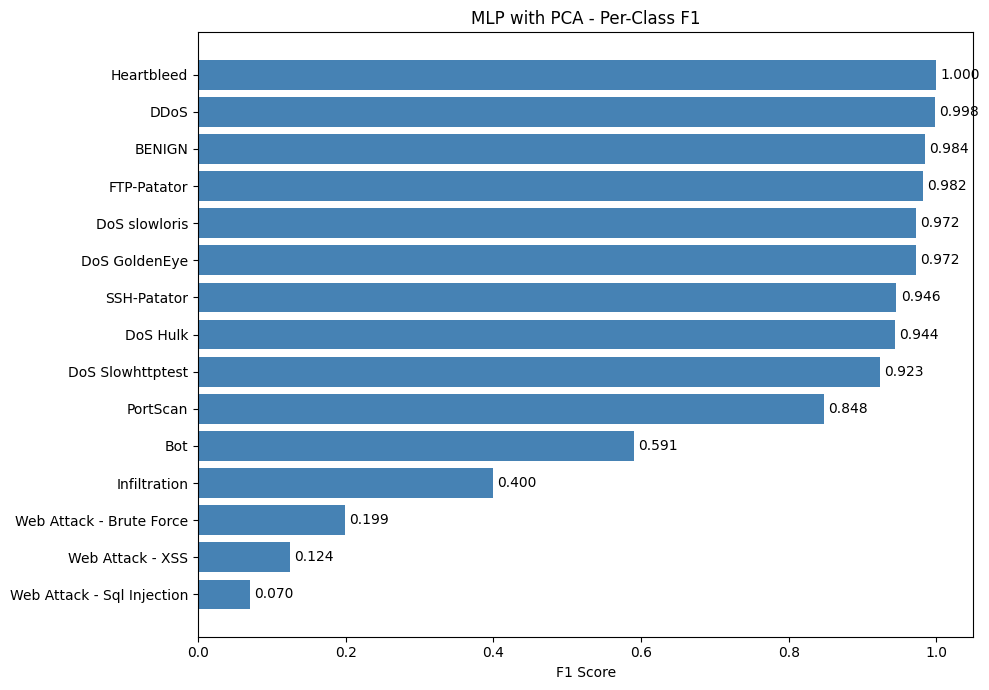

Saved results/mlp_pca_f1.png


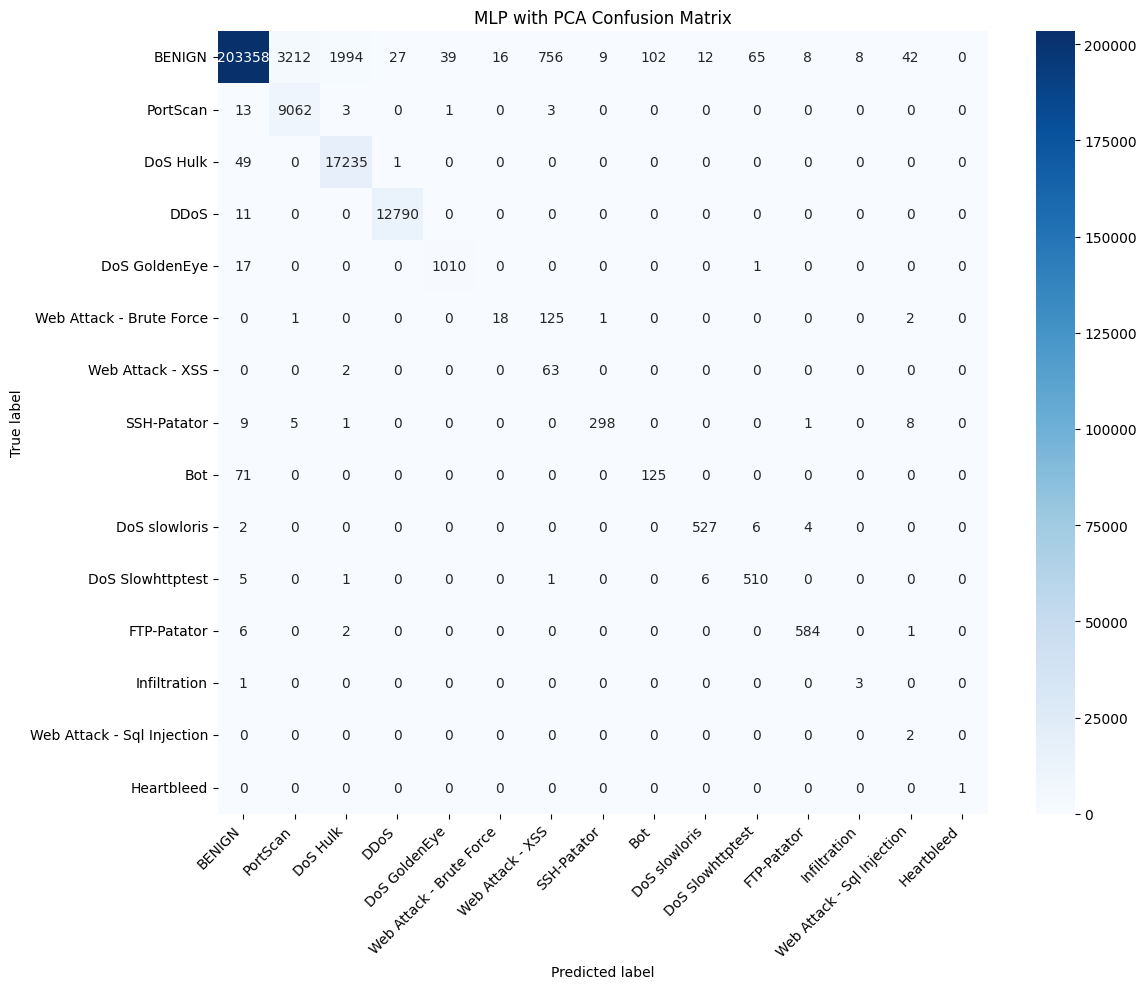

<Axes: title={'center': 'MLP with PCA Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

In [25]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP with PCA", y_test, mlp_predict(mlp_artifacts, X_test_pca))
save_classification_report(mlp_result, RESULTS / "mlp_pca_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_pca_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_pca_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_pca_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP with PCA - Per-Class F1",
	save_path=str(RESULTS / "mlp_pca_f1.png")
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "mlp_pca_conf.png")
)

save_training_curves(
    mlp_artifacts.history,
    model_name="MLP with PCA",
    save_path=str(RESULTS / "mlp_pca_curve.png")
)

In [20]:
import time
# mlp training
from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

t0 = time.time()
mlp_artifacts = train_mlp_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.3,
	random_state=42,
	verbose=1
)
mlp_train_time = time.time() - t0
print(f"MLP training complete. ({mlp_train_time:.1f}s)")


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_4 (Normalization) │ (None, 61)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,914 (234.04 KB)

 Trainable params: 58,895 (230.06 KB)

 Non-trainable params: 1,019 (3.98 KB)

None
Epoch 1/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9471 - cross_entropy: 0.1555 - loss: 0.1842 - val_accuracy: 0.9655 - val_cross_entropy: 0.0709 - val_loss: 0.0709
Epoch 2/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9610 - cross_entropy: 0.0985 - loss: 0.0985 - val_accuracy: 0.9663 - val_cross_entropy: 0.0636 - val_loss: 0.0636
Epoch 3/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9647 - cross_entropy: 0.0866 - loss: 0.0866 - val_accuracy: 0.9720 - val_cross_entropy: 0.0583 - val_loss: 0.0583
Epoch 4/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9665 - cross_entropy: 0.0815 - loss: 0.0815 - val_accuracy: 0.9715 - val_cross_entropy: 0.0582 - val_loss: 0.0582
Epoch 5/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9679 - cross_entropy: 0.0781 - loss: 0.0781 - val_accuracy: 0.9702 - val_cross_entropy: 0.0612 - val_loss: 0.0612
Epoch 6/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9688 - cros

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.988     0.994    209648
                  PortScan      0.977     0.998     0.987      9082
                  DoS Hulk      0.935     1.000     0.966     17285
                      DDoS      0.996     1.000     0.998     12801
             DoS GoldenEye      0.965     0.983     0.974      1028
  Web Attack - Brute Force      0.812     0.088     0.160       147
          Web Attack - XSS      0.067     0.969     0.125        65
               SSH-Patator      0.980     0.922     0.950       322
                       Bot      0.466     0.673     0.551       196
             DoS slowloris      0.957     0.981     0.969       539
          DoS Slowhttptest      0.883     0.977     0.927       523
               FTP-Patator      0.917     0.987     0.950       593
              Infiltration      0.333     0.750     0.462         4
Web Attack - Sql Injection      0.032     1.000

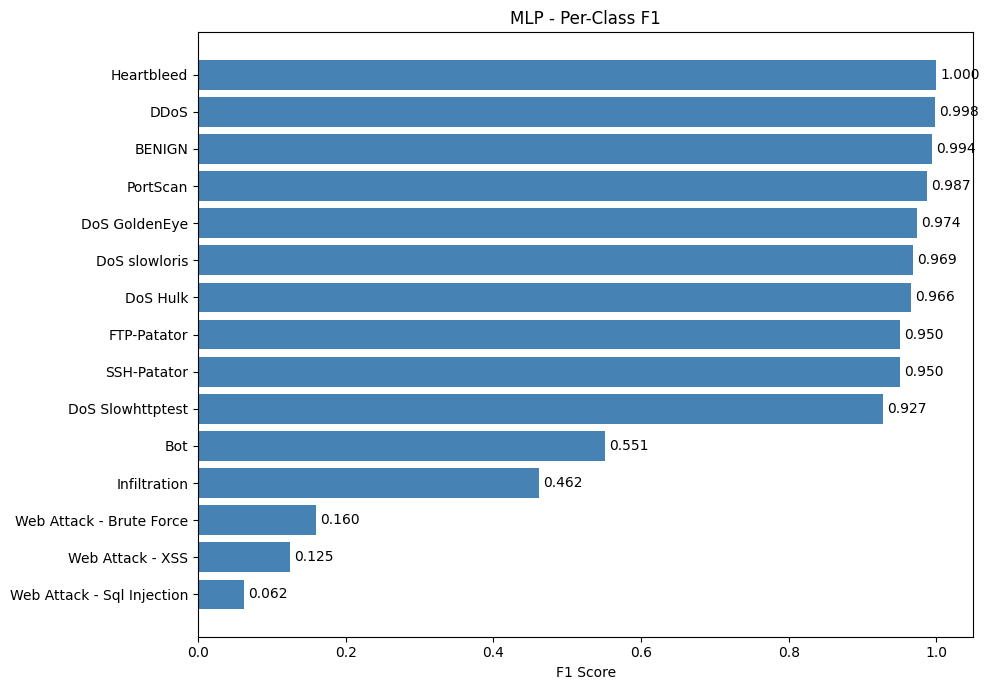

Saved results/mlp_f1.png


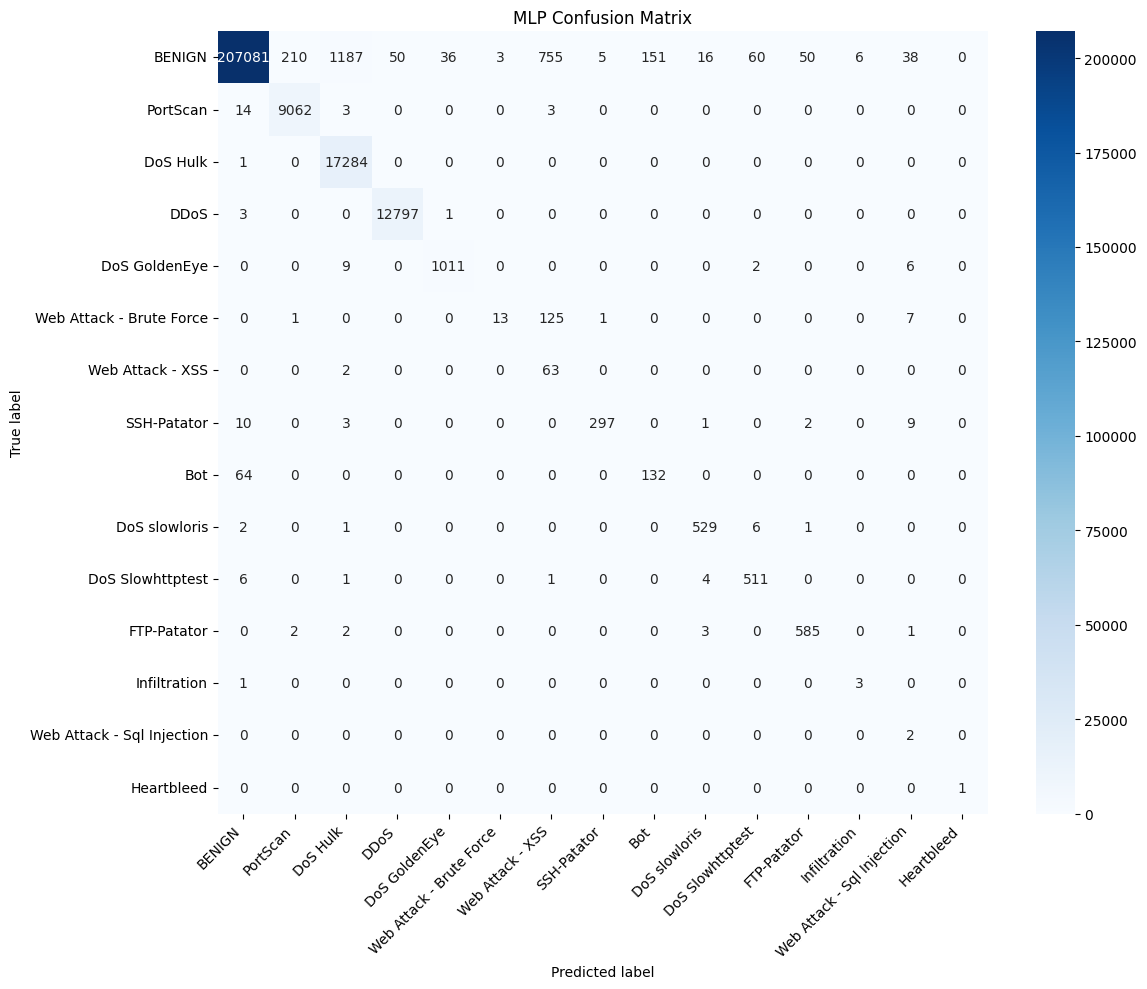

<Axes: title={'center': 'MLP Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

In [22]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP", y_test, mlp_predict(mlp_artifacts, X_test))
save_classification_report(mlp_result, RESULTS / "mlp_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP - Per-Class F1",
	save_path=str(RESULTS / "mlp_f1.png")
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "mlp_conf.png")
)

save_training_curves(
    mlp_artifacts.history,
    model_name="MLP",
    save_path=str(RESULTS / "mlp_curve.png")
)

# save training history for interactive Plotly display in Streamlit
(RESULTS / "mlp_history.json").write_text(
    json.dumps({k: [float(v) for v in vs] for k, vs in mlp_artifacts.history.items()})
)
print("MLP history saved.")


In [30]:
import time
# cnn training
from src.models.cnn import train_cnn_classifier, predict_labels as cnn_predict

t0 = time.time()
cnn_artifacts = train_cnn_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=128,
	early_stopping_patience=10,
	learning_rate=1e-3,
	verbose=1,
	conv_filters=(64,32),
	dense_units=64,
	dropout_rate=0.0,
)
cnn_train_time = time.time() - t0
print(f"CNN training complete. ({cnn_train_time:.1f}s)")


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 61, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,191 (149.18 KB)

 Trainable params: 38,191 (149.18 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
6718/6718 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9582 - cross entropy: 0.1116 - loss: 0.1239 - val_accuracy: 0.9744 - val_cross entropy: 0.0591 - val_loss: 0.0591
Epoch 2/30
6718/6718 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9714 - cross entropy: 0.0692 - loss: 0.0692 - val_accuracy: 0.9740 - val_cross entropy: 0.0547 - val_loss: 0.0547
Epoch 3/30
6718/6718 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9744 - cross entropy: 0.0603 - loss: 0.0603 - val_accuracy: 0.9753 - val_cross entropy: 0.0494 - val_loss: 0.0494
Epoch 4/30
6718/6718 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9758 - cross entropy: 0.0566 - loss: 0.0566 - val_accuracy: 0.9769 - val_cross entropy: 0.0460 - val_loss: 0.0460
Epoch 5/30
6718/6718 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9766 - cross entropy: 0.0543 - loss: 0.0543 - val_accuracy: 0.9781 - val_cross entropy: 0.0452 - val_loss: 0.0452
Epoch 6/30
6718/6718 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9770 - cros

                            precision    recall  f1-score   support

                    BENIGN      0.999     0.994     0.997    209648
                  PortScan      0.986     0.999     0.992      9082
                  DoS Hulk      0.989     0.997     0.993     17285
                      DDoS      0.999     1.000     1.000     12801
             DoS GoldenEye      0.984     0.989     0.986      1028
  Web Attack - Brute Force      0.225     0.272     0.246       147
          Web Attack - XSS      0.096     0.985     0.176        65
               SSH-Patator      0.957     0.957     0.957       322
                       Bot      0.467     0.801     0.590       196
             DoS slowloris      0.982     0.993     0.987       539
          DoS Slowhttptest      0.887     0.989     0.935       523
               FTP-Patator      1.000     0.988     0.994       593
              Infiltration      0.300     0.750     0.429         4
Web Attack - Sql Injection      0.061     1.000

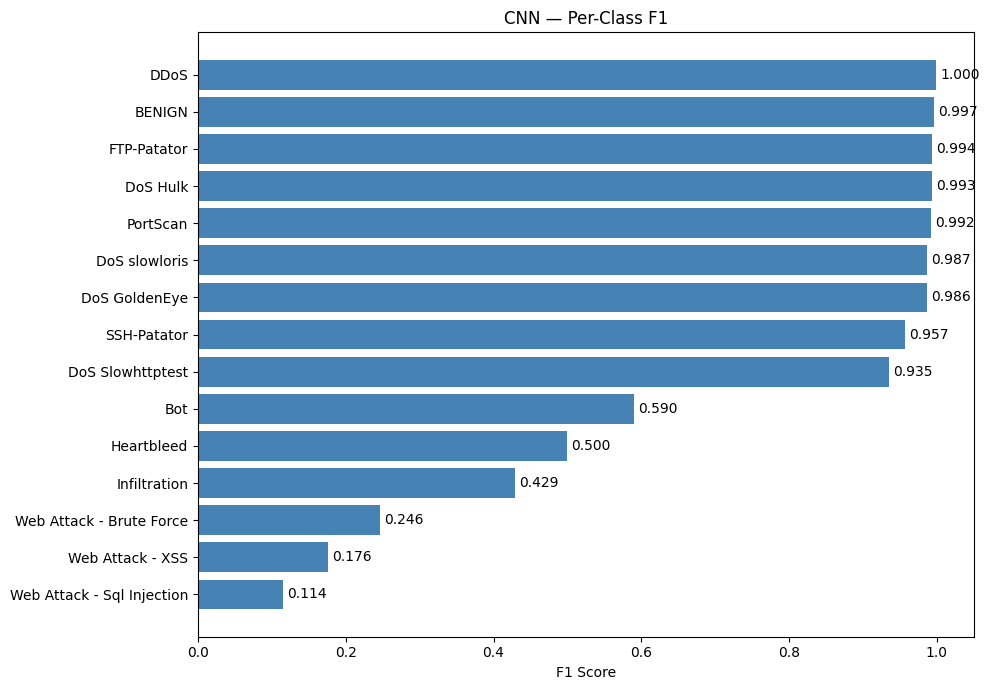

Saved results/cnn_f1.png


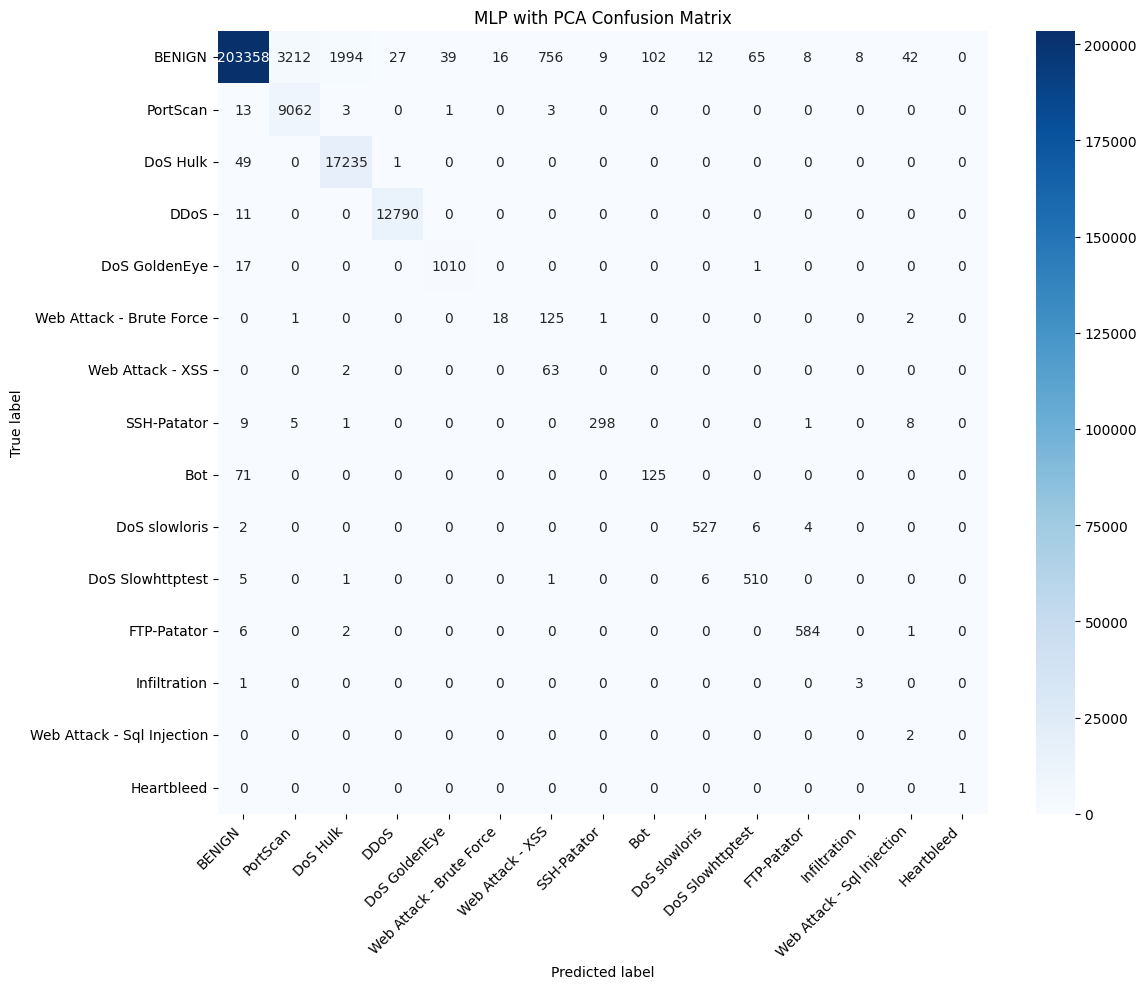

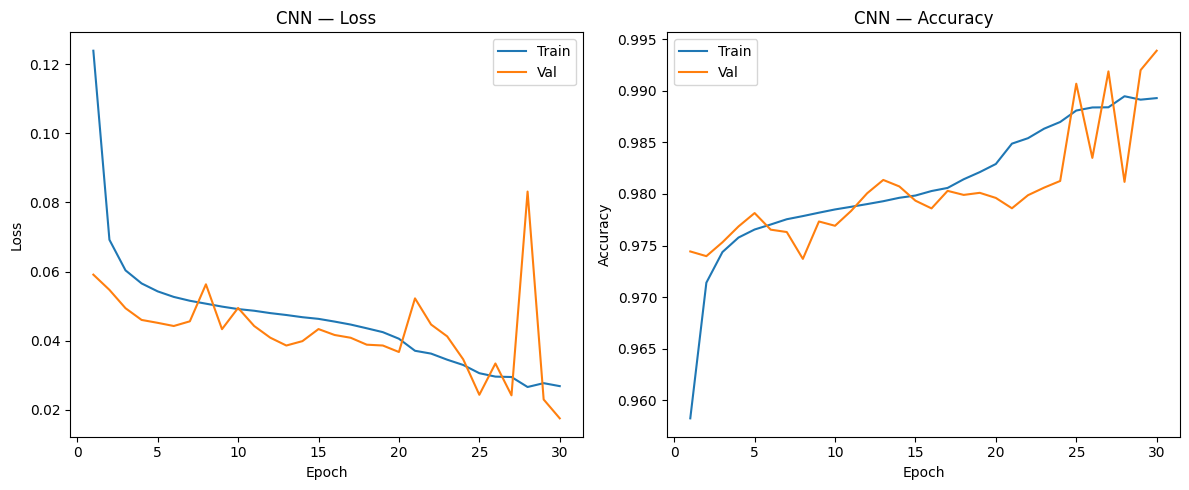

Saved results/cnn_curve.png


In [32]:


cnn_result = evaluate_model_predictions("CNN", y_test, cnn_predict(cnn_artifacts, X_test))
save_classification_report(cnn_result, RESULTS / "cnn_report.txt")

cnn_report_dict = cnn_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "cnn_report.json").write_text(json.dumps(cnn_report_dict))

cnn_artifacts.model.save(RESULTS / "cnn_model.keras")
with open(RESULTS / "cnn_scaler.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.scaler, f)
with open(RESULTS / "cnn_encoder.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.label_encoder, f)

print(cnn_result.classification_report_text)

save_f1_chart(
    cnn_report_dict,
    title="CNN — Per-Class F1",
    save_path=str(RESULTS / "cnn_f1.png"),
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "cnn_conf.png")
)

save_training_curves(
    cnn_artifacts.history,
    model_name="CNN",
    save_path=str(RESULTS / "cnn_curve.png")
)

# save training history for interactive Plotly display in Streamlit
(RESULTS / "cnn_history.json").write_text(
    json.dumps({k: [float(v) for v in vs] for k, vs in cnn_artifacts.history.items()})
)
print("CNN history saved.")


In [ ]:
# collect and save training times for all 5 models
training_times = {
    "Logistic Regression": round(lr_train_time, 1),
    "Random Forest": round(rf_train_time, 1),
    "LightGBM": round(lgbm_train_time, 1),
    "MLP": round(mlp_train_time, 1),
    "CNN": round(cnn_train_time, 1),
}
(RESULTS / "training_times.json").write_text(json.dumps(training_times))
print("Training times saved:")
for name, t in training_times.items():
    print(f"  {name}: {t}s")


In [29]:
# cnn training
# 1D convolutional neural network. Uses early stopping on validation loss (patience=10). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.cnn import train_cnn_classifier, predict_labels as cnn_predict


cnn_artifacts = train_cnn_classifier(
	X_fit_pca,
	y_resampled,
	X_valid=X_val_pca,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	learning_rate=1e-3,
	verbose=1,
    conv_filters=(64,32),
    dense_units=64,
    dropout_rate=0.0,
)
print("CNN training complete.")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 25, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,759 (77.18 KB)

 Trainable params: 19,759 (77.18 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9476 - cross entropy: 0.1549 - loss: 0.1866 - val_accuracy: 0.9703 - val_cross entropy: 0.0695 - val_loss: 0.0695
Epoch 2/30
2872/3359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9603 - cross entropy: 0.1011 - loss: 0.1011

KeyboardInterrupt: 

In [ ]:


cnn_result = evaluate_model_predictions("CNN with PCA", y_test, cnn_predict(cnn_artifacts, X_test))
save_classification_report(cnn_result, RESULTS / "cnn_pca_report.txt")

cnn_report_dict = cnn_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "cnn_pca_report.json").write_text(json.dumps(cnn_report_dict))

cnn_artifacts.model.save(RESULTS / "cnn_pca_model.keras")
with open(RESULTS / "cnn_pca_scaler.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.scaler, f)
with open(RESULTS / "cnn_pca_encoder.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.label_encoder, f)

print(cnn_result.classification_report_text)

save_f1_chart(
    cnn_report_dict,
    title="CNN with PCA — Per-Class F1",
    save_path=str(RESULTS / "cnn_pca_f1.png"),
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "cnn_pca_conf.png")
)

save_training_curves(
    cnn_artifacts.history,
    model_name="CNN with PCA",
    save_path=str(RESULTS / "cnn_pca_curve.png")
)

### Model Comparisons